# Импорты

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.linalg import svd

# Для адаптивной окрестности - попарные расстояния
from scipy.spatial.distance import pdist

# Функции

## Код предобработки, SVD, RankMe

In [ ]:
def center_embeddings_relative_to_center(embeddings, center_index):
    """
    Центрирует эмбеддинги относительно точки с индексом center_index.
    """
    center = embeddings[center_index]
    return embeddings - center


def find_epsilon_neighborhood(X, center_index, epsilon):
    """
    Находит все точки в эпсилон-окрестности относительно точки с индексом center_index в X.
    """
    distances = cdist(X[center_index].reshape(1, -1), X, metric="euclidean")
    distances = distances.flatten()

    in_epsilon = distances <= epsilon  # Все точки внутри эпсилон-окрестности
    all_indices = np.where(in_epsilon)[0]  # Индексы точек в окрестности

    return all_indices


def find_k_nearest_neighbors(X, center_index, k=4):
    """
    Находит k ближайших соседей относительно точки с индексом center_index в X.
    """
    distances = cdist(X[center_index].reshape(1, -1), X, metric="euclidean")
    distances = distances.flatten()
    sorted_indices = np.argsort(distances)
    return sorted_indices[1 : k + 1]


def rankme(s):
    norm_1 = np.sum(np.abs(s))
    p_k = np.abs(s) / (norm_1 + 1e-10)
    entropy = -np.sum(p_k * np.log(p_k + 1e-10))
    rankme_value = np.exp(entropy)

    return rankme_value


def get_local_centered_neighborhood(X, Y, center_index, k=None, epsilon=None):
    """
    Возвращает центрированные X_centered, Y_centered для одной локальной окрестности.
    ИЛИ по k ближайших соседей, ИЛИ по эпсилон-окрестности.
    """
    # Проверка
    if (k is None and epsilon is None) or (k is not None and epsilon is not None):
        raise ValueError("Должен быть указан ровно один из параметров: k или epsilon")

    # Для эпсилон-окрестности
    if k is None:
        neighbors_indices = find_epsilon_neighborhood(
            X, center_index, epsilon
        )  # Все точки в эпсилон-окрестности

        # Достаточно ли точек для анализа
        if len(neighbors_indices) < 3:
            return None, None

        # Проверка присутствия центральной точки в окрестности
        if center_index not in neighbors_indices:
            return None, None
        center_pos_in_neighbors = np.where(neighbors_indices == center_index)[0][
            0
        ]  # Позиция центральной точки

        # Центрирование относительно центральной точки
        X_centered = center_embeddings_relative_to_center(
            X[neighbors_indices], center_pos_in_neighbors
        )
        Y_centered = center_embeddings_relative_to_center(
            Y[neighbors_indices], center_pos_in_neighbors
        )

    # Для k ближайших
    else:
        neighbors_indices = find_k_nearest_neighbors(X, center_index, k)
        all_indices = np.concatenate(
            [[center_index], neighbors_indices]
        )  # Добавление центральной точки в окрестность
        center_pos_in_neighbors = 0  # Центральная точка всегда на позиции 0

        X_centered = center_embeddings_relative_to_center(
            X[all_indices], center_pos_in_neighbors
        )
        Y_centered = center_embeddings_relative_to_center(
            Y[all_indices], center_pos_in_neighbors
        )

    return X_centered, Y_centered


def solve_local_linear_map_and_rank(X_centered, Y_centered, use_softrank=True):
    """
    Решает X_centered * M \approx Y_centered и возвращает метрику (RankMe или жесткий ранг), M и сингулярные числа.
    """
    M = np.linalg.pinv(X_centered).dot(
        Y_centered
    )  # X_centered * M \approx Y_centered с помощью псевдообратной матрицы
    U, s, Vt = svd(M, full_matrices=False)  # Сингулярные числа матрицы M

    if use_softrank:  # RankMe
        metric_value = rankme(s)

    else:  # Жесткий ранг
        threshold = 1e-10 * np.max(s)  # Порог для определения нулевых значений
        metric_value = np.sum(s > threshold)

    return metric_value, M, s

##Код метрики

In [ ]:
# 1) Линейный подход
def compute_metric_linear(X, Y, center_index, k=None, epsilon=None, use_softrank=True):
    """
    Линейная версия метрики (твой текущий подход).
    """
    X_centered, Y_centered = get_local_centered_neighborhood(
        X, Y, center_index, k=k, epsilon=epsilon
    )
    if X_centered is None:
        return np.nan, None, None

    metric_value, M, s = solve_local_linear_map_and_rank(
        X_centered, Y_centered, use_softrank=use_softrank
    )
    return metric_value, M, s


# 2) Мульти-масштаб
def compute_metric_multiscale(
    X,
    Y,
    center_index,
    k_list=None,
    epsilon_list=None,
    aggregator="mean",
    use_softrank=True,
):
    """
    Мульти-масштабная версия метрики: считает метрику на нескольких размерах окрестности и агрегирует.
    aggregator: "mean" | "min" | "max"
    """
    # Проверка
    if (k_list is None and epsilon_list is None) or (
        k_list is not None and epsilon_list is not None
    ):
        raise ValueError(
            "Должен быть указан ровно один из параметров: k_list или epsilon_list"
        )

    values = []
    last_M = None
    last_s = None

    # Для k ближайших
    if k_list is not None:
        for k in k_list:
            v, M, s = compute_metric_linear(
                X, Y, center_index, k=k, epsilon=None, use_softrank=use_softrank
            )
            if not np.isnan(v):
                values.append(v)
                last_M = M
                last_s = s

    # Для эпсилон-окрестности
    else:
        for eps in epsilon_list:
            v, M, s = compute_metric_linear(
                X, Y, center_index, k=None, epsilon=eps, use_softrank=use_softrank
            )
            if not np.isnan(v):
                values.append(v)
                last_M = M
                last_s = s

    if len(values) == 0:
        return np.nan, None, None

    if aggregator == "mean":
        return float(np.mean(values)), last_M, last_s
    if aggregator == "min":
        return float(np.min(values)), last_M, last_s
    if aggregator == "max":
        return float(np.max(values)), last_M, last_s

    raise ValueError("aggregator должен быть одним из: mean, min, max")


# 3) Нелинейность через Random Fourier Features (kernel-подход без обучения)
def rff_features(X, n_features=256, gamma=1.0, random_seed=42):
    """
    Random Fourier Features для RBF-ядра.
    Возвращает Phi(X) размерности (n_samples, n_features).
    """
    rng = np.random.RandomState(random_seed)
    d = X.shape[1]

    W = rng.normal(loc=0.0, scale=np.sqrt(2 * gamma), size=(d, n_features))
    b = rng.uniform(low=0.0, high=2 * np.pi, size=(n_features,))

    Phi = np.sqrt(2.0 / n_features) * np.cos(X.dot(W) + b)
    return Phi


def compute_metric_rff(
    X,
    Y,
    center_index,
    k=None,
    epsilon=None,
    n_features=256,
    gamma=1.0,
    rff_seed=42,
    use_softrank=True,
):
    """
    Нелинейная версия метрики через Random Fourier Features (приближение RBF-ядра).
    """
    X_centered, Y_centered = get_local_centered_neighborhood(
        X, Y, center_index, k=k, epsilon=epsilon
    )
    if X_centered is None:
        return np.nan, None, None

    Phi = rff_features(
        X_centered, n_features=n_features, gamma=gamma, random_seed=rff_seed
    )

    metric_value, M, s = solve_local_linear_map_and_rank(
        Phi, Y_centered, use_softrank=use_softrank
    )
    return metric_value, M, s


def compute_metric(
    X,
    Y,
    center_index,
    k=None,
    epsilon=None,
    use_softrank=True,
    method="linear",
    k_list=None,
    epsilon_list=None,
    aggregator="mean",
    n_features=256,
    gamma=1.0,
    rff_seed=42,
):
    """
    Вычисляет метрику сравнения пространств для заданной центральной точки.
    ИЛИ по k ближайших соседей, ИЛИ по эпсилон-окрестности.

    Args:
        X: эмбеддинги пространства A (n_samples, dim_a)
        Y: эмбеддинги пространства B (n_samples, dim_b) для ТЕХ ЖЕ объектов
        center_index: индекс центральной точки
        k: размер локальной окрестности
        epsilon: радиус окрестности
        use_softrank: если True - использовать softrank (энтропию), иначе - жесткий ранг

    Returns:
        metric_value: значение метрики
        M: найденная матрица преобразования (для анализа)
        s: сингулярные числа матрицы M
    """
    # Линейная версия
    if method == "linear":
        return compute_metric_linear(
            X, Y, center_index, k=k, epsilon=epsilon, use_softrank=use_softrank
        )

    # Мульти-масштабная версия
    if method == "multiscale":
        return compute_metric_multiscale(
            X,
            Y,
            center_index,
            k_list=k_list,
            epsilon_list=epsilon_list,
            aggregator=aggregator,
            use_softrank=use_softrank,
        )

    # Нелинейная версия через RFF
    if method == "rff":
        return compute_metric_rff(
            X,
            Y,
            center_index,
            k=k,
            epsilon=epsilon,
            n_features=n_features,
            gamma=gamma,
            rff_seed=rff_seed,
            use_softrank=use_softrank,
        )

    raise ValueError("method должен быть одним из: linear, multiscale, rff")


def compute_global_metric(
    X,
    Y,
    n_samples=100,
    k=None,
    epsilon=None,
    random_seed=42,
    method="linear",
    k_list=None,
    epsilon_list=None,
    aggregator="mean",
    n_features=256,
    gamma=1.0,
    rff_seed=42,
):
    """
    Вычисляет глобальную метрику, усредняя по случайным точкам.

    Args:
        X: эмбеддинги пространства A
        Y: эмбеддинги пространства B
        n_samples: количество случайных точек для усреднения
        k: размер локальной окрестности (если используется k-NN)
        epsilon: радиус окрестности (если используется эпсилон-окрестность)
        random_seed: seed для воспроизводимости

    Returns:
        mean_metric: среднее значение метрики
        std_metric: стандартное отклонение
        all_values: все значения метрик
    """
    np.random.seed(random_seed)

    n = X.shape[0]
    if n_samples > n:
        n_samples = n

    random_indices = np.random.choice(
        n, size=n_samples, replace=False
    )  # Выбор случайных центральных точек

    all_values = []
    for idx in random_indices:
        metric_value, _, _ = compute_metric(
            X,
            Y,
            idx,
            k=k,
            epsilon=epsilon,
            use_softrank=True,
            method=method,
            k_list=k_list,
            epsilon_list=epsilon_list,
            aggregator=aggregator,
            n_features=n_features,
            gamma=gamma,
            rff_seed=rff_seed,
        )
        if not np.isnan(metric_value):
            all_values.append(metric_value)

    return np.mean(all_values), np.std(all_values), np.array(all_values)

Нелинейности:
1. **Мультимасштаб**. Просто берём разные радиусы окрестности (или число соседей) одной и той же центральной точки $x_0$, находим матрицу $M$ для каждого случая и аггрегируем. Мультимасштаб позволяет обнаружить нелинейность, искривления представления *по сравнению с линейной версией метрики*, но сама нелинейнеость не вводит, лишь позволяет обнаружить. Формула: $$\operatorname{Metric}(x_0)=\frac{1}{\mathcal{R}}\sum_{r\in\mathcal{R}}\operatorname{RankMe}(M(r))$$
2. **Random Fourier Features (RFF)**. Вводится нелинейное ядро отображения ${\Phi}:\mathbb{R}^{d_x}\to\mathbb{R}^{m}$. То есть, вместо нахождения линейного $\tilde{X}M\approx \tilde{Y}$ я нахожу $\Phi\left(\tilde{X}\right)M\approx \tilde{Y}$. По идее, эта метрика должна учитывать нелинейность в признаках при всё той же линейности $M$. RFF - потому что оно локальное, изотропное, не искажает размерности, не маскирует схлопывания размерностей. При этом сам ранг начинает измеряться не в линейном пространстве, а в пространстве их нелиненых вариаций (отклонений от линейности), т.е. ловит кривизну отображения.

# Тесты на синтетике

In [ ]:
def test_comparison(X, Y):
    """
    Сравнение методов k-NN и эпсилон-окрестности.
    """
    center_index = 0

    # 1. k-NN метод (линейный)
    print("=== Метод k-NN (k=10) [linear] ===")
    metric_k, M_k, s_k = compute_metric(X, Y, center_index, k=10, method="linear")
    mean_k, std_k, values_k = compute_global_metric(
        X, Y, k=10, n_samples=500, method="linear"
    )
    print(f"Локальная метрика: {metric_k:.4f}")
    print(f"Глобальная метрика: {mean_k:.4f} ± {std_k:.4f}")

    # 2. эпсилон-метод (линейный)
    print("\n=== Метод эпсилон-окрестности [linear] ===")
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    Y_norm = (Y - Y.mean(axis=0)) / Y.std(axis=0)

    # Адаптивный эпсилон на основе статитики попарных расстояний и процентиля
    sample_idx = np.random.choice(X_norm.shape[0], size=500, replace=False)
    distances = pdist(X_norm[sample_idx])
    epsilon = np.percentile(distances, 10)
    print(f"Выбранный адаптивный эпсилон: {epsilon:.4f}")

    metric_eps, M_eps, s_eps = compute_metric(
        X_norm, Y_norm, center_index, epsilon=epsilon, method="linear"
    )
    mean_eps, std_eps, values_eps = compute_global_metric(
        X_norm, Y_norm, epsilon=epsilon, n_samples=500, method="linear"
    )
    print(f"Локальная метрика: {metric_eps:.4f}")
    print(f"Глобальная метрика: {mean_eps:.4f} ± {std_eps:.4f}")

    # 3. мульти-масштаб (пример по k)
    print("\n=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===")
    metric_ms, M_ms, s_ms = compute_metric(
        X,
        Y,
        center_index,
        method="multiscale",
        k_list=[5, 10, 20, 40],
        aggregator="mean",
    )
    mean_ms, std_ms, values_ms = compute_global_metric(
        X,
        Y,
        n_samples=500,
        method="multiscale",
        k_list=[5, 10, 20, 40],
        aggregator="mean",
    )
    print(f"Локальная метрика: {metric_ms:.4f}")
    print(f"Глобальная метрика: {mean_ms:.4f} ± {std_ms:.4f}")

    # 4. RFF (пример)
    print("\n=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===")
    metric_rff, M_rff, s_rff = compute_metric(
        X, Y, center_index, k=10, method="rff", n_features=256, gamma=1.0, rff_seed=42
    )
    mean_rff, std_rff, values_rff = compute_global_metric(
        X, Y, n_samples=500, k=10, method="rff", n_features=256, gamma=1.0, rff_seed=42
    )
    print(f"Локальная метрика: {metric_rff:.4f}")
    print(f"Глобальная метрика: {mean_rff:.4f} ± {std_rff:.4f}")

    # Графики
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(
        values_k, bins=15, alpha=0.5, edgecolor=None, label=f"linear k-NN: {mean_k:.3f}"
    )
    plt.hist(
        values_eps,
        bins=15,
        alpha=0.5,
        edgecolor=None,
        label=f"linear eps: {mean_eps:.3f}",
    )
    plt.hist(
        values_ms,
        bins=15,
        alpha=0.5,
        edgecolor=None,
        label=f"multiscale: {mean_ms:.3f}",
    )
    plt.hist(
        values_rff, bins=15, alpha=0.5, edgecolor=None, label=f"rff: {mean_rff:.3f}"
    )

    # Вертикальные линии средних
    plt.axvline(mean_k, color="blue", linestyle="--", linewidth=1)
    plt.axvline(mean_eps, color="red", linestyle="--", linewidth=1)
    plt.axvline(mean_ms, color="green", linestyle="--", linewidth=1)
    plt.axvline(mean_rff, color="black", linestyle="--", linewidth=1)

    plt.xlabel("Значение метрики")
    plt.ylabel("Частота")
    plt.title("Распределение локальных метрик")
    plt.legend()

    plt.subplot(1, 2, 2)
    # Максимально возможный softrank: без паддинга это min(dim_a, dim_b)
    dim_a, dim_b = X.shape[1], Y.shape[1]
    max_rank = min(dim_a, dim_b)
    x_positions = np.arange(1, max_rank + 1)

    if s_k is not None:
        plt.plot(x_positions[: len(s_k)], s_k, "bo-", label="linear k-NN", markersize=6)
    if s_eps is not None and len(s_eps) > 0:
        plt.plot(
            x_positions[: len(s_eps)], s_eps, "ro-", label="linear eps", markersize=6
        )
    if s_ms is not None and len(s_ms) > 0:
        plt.plot(
            x_positions[: len(s_ms)],
            s_ms,
            "go-",
            label="multiscale (last)",
            markersize=6,
        )
    if s_rff is not None and len(s_rff) > 0:
        plt.plot(x_positions[: len(s_rff)], s_rff, "ko-", label="rff", markersize=6)

    plt.axhline(y=0, color=None, linestyle="-", alpha=0)
    plt.xlabel("Номер сингулярного числа")
    plt.ylabel("Значение")
    plt.title("Сингулярные числа матрицы M (или W)")
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

    # Анализ
    print(f"\n{'='*30}")
    print("АНАЛИЗ РЕЗУЛЬТАТОВ:")
    print("=" * 30)
    print(f"Максимально возможный softrank: {max_rank}")
    print(f"k-NN: {mean_k:.2f} ({mean_k/max_rank*100:.1f}%)")
    print(f"Эпсилон: {mean_eps:.2f} ({mean_eps/max_rank*100:.1f}%)")
    print(f"Multiscale: {mean_ms:.2f} ({mean_ms/max_rank*100:.1f}%)")
    print(f"RFF: {mean_rff:.2f} ({mean_rff/max_rank*100:.1f}%)")

    return {
        "linear_knn": {
            "local": metric_k,
            "global": mean_k,
            "std": std_k,
            "values": values_k,
            "singular_values": s_k,
        },
        "linear_epsilon": {
            "local": metric_eps,
            "global": mean_eps,
            "std": std_eps,
            "values": values_eps,
            "singular_values": s_eps,
        },
        "multiscale": {
            "local": metric_ms,
            "global": mean_ms,
            "std": std_ms,
            "values": values_ms,
            "singular_values": s_ms,
        },
        "rff": {
            "local": metric_rff,
            "global": mean_rff,
            "std": std_rff,
            "values": values_rff,
            "singular_values": s_rff,
        },
    }

=== Метод k-NN (k=10) [linear] ===
Локальная метрика: 7.0075
Глобальная метрика: 6.4413 ± 1.1934

=== Метод эпсилон-окрестности [linear] ===
Выбранный адаптивный эпсилон: 3.1496
Локальная метрика: 7.2816
Глобальная метрика: 7.2941 ± 0.0185

=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===
Локальная метрика: 6.4820
Глобальная метрика: 6.3211 ± 0.3021

=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===
Локальная метрика: 6.3176
Глобальная метрика: 6.2218 ± 0.3310


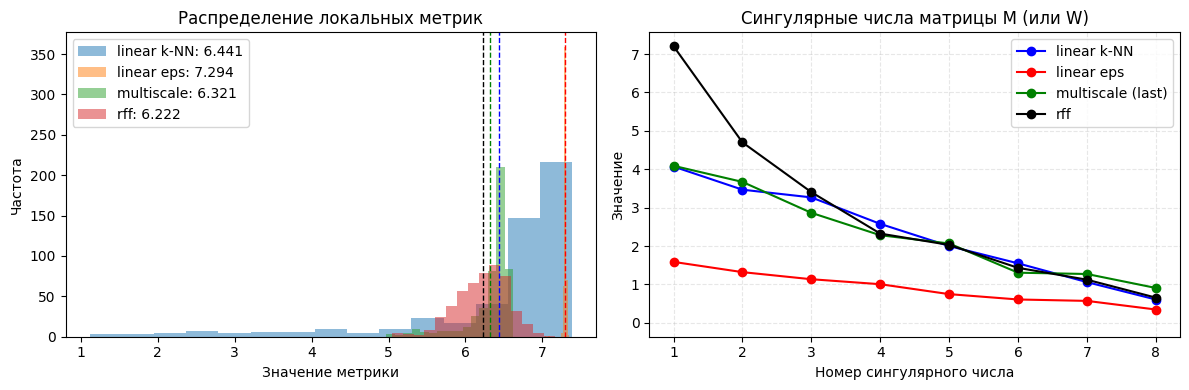


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 8
k-NN: 6.44 (80.5%)
Эпсилон: 7.29 (91.2%)
Multiscale: 6.32 (79.0%)
RFF: 6.22 (77.8%)


In [ ]:
# Линейные тестовые данные
np.random.seed(42)
n_objects = 10000
dim_a, dim_b = 10, 8

X = np.random.randn(n_objects, dim_a)
M_true = np.random.randn(dim_a, dim_b) * 0.8
Y = X.dot(M_true) + np.random.randn(n_objects, dim_b) * 0.1

# Запуск теста
results = test_comparison(X, Y)

Здесь важно наиболее внимательно посмотреть на линейные методы, так как данные линеные.

1. В линейной синтетике эпсилон-окрестность выигрывает по устойчивости, потому что даёт большие и почти одинаковые по размеру локальные выборки.

2. Метод k-NN будет устойчивым тоже, если k достаточно большой относительно размерности. Его стоит подобрать. Также надо посмотреть, как обычно устроена плотность эмбеддингов в реальных кейсах.

>Пока затрудняюсь в выборе между линейными подходами - основе метрики. Окрестность кажется более устойчивой.

=== Метод k-NN (k=10) [linear] ===
Локальная метрика: 6.3707
Глобальная метрика: 4.2829 ± 1.4002

=== Метод эпсилон-окрестности [linear] ===
Выбранный адаптивный эпсилон: 3.1496
Локальная метрика: 7.3962
Глобальная метрика: 7.0160 ± 0.3555

=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===
Локальная метрика: 6.3908
Глобальная метрика: 5.2230 ± 0.5026

=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===
Локальная метрика: 6.4517
Глобальная метрика: 5.6873 ± 0.5351


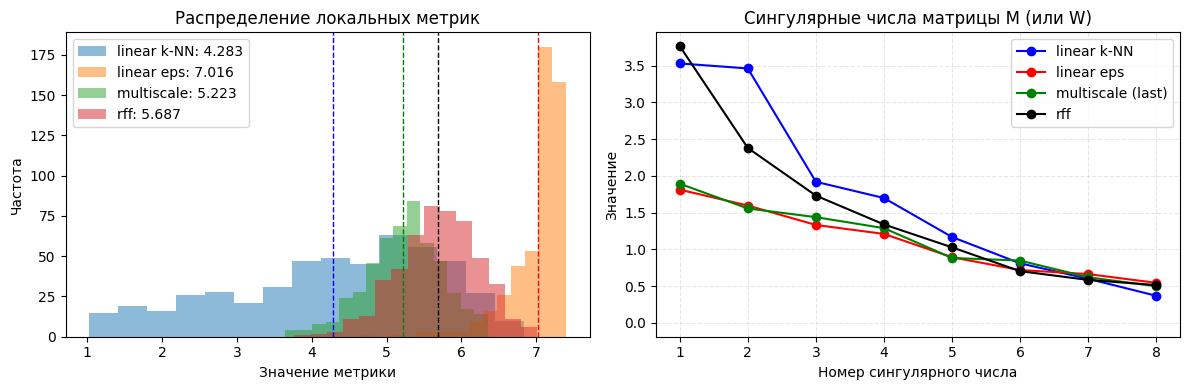


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 8
k-NN: 4.28 (53.5%)
Эпсилон: 7.02 (87.7%)
Multiscale: 5.22 (65.3%)
RFF: 5.69 (71.1%)


In [ ]:
# Нелинейные тестовые данные (tanh)

np.random.seed(42)
n_objects = 10000
dim_a, dim_b = 10, 8

X = np.random.randn(n_objects, dim_a)

M_true = np.random.randn(dim_a, dim_b) * 0.8

# Нелинейное отображение
Y = np.tanh(X.dot(M_true)) + np.random.randn(n_objects, dim_b) * 0.05

# Запуск теста
results = test_comparison(X, Y)

В эксперименте рассматривалось нелинейное отображение вида $Y=\tanh(XM_{\operatorname{true}})+\varepsilon$, где исходное линейное преобразование дополнительно искажается нелинейной активацией.

Полученные результаты показывают следующее.

1. Базовая линейная версия метрики демонстрирует заметное снижение значения `softrank` по сравнению с линейным эталонным случаем. Это указывает на то, что нелинейное отображение приводит к эффективному схлопыванию локальной размерности: часть направлений вариации в пространстве $X$ перестаёт линейно передаваться в пространство $Y$.

2. Мульти-масштабная версия метрики даёт значения, близкие к линейной, но с меньшей дисперсией. Это означает, что агрегирование по нескольким масштабам сглаживает локальные флуктуации, возникающие из-за кривизны отображения и конечного числа точек в окрестностях, однако не восстанавливает утраченные степени свободы (размерности). Таким образом, мульти-масштабный подход повышает устойчивость оценки, но не маскирует нелинейные эффекты.

3. Использование нелинейного перепредставления входных данных с помощью `Random Fourier Features` не приводит к росту `softrank` по сравнению с линейной моделью. Это показывает, что в данном эксперименте нелинейность носит характер сжатия пространства (например, за счёт насыщения функции $\tanh$), а не простого изгиба, который мог бы быть устранён переходом в более богатое признаковое пространство. Следовательно, потеря эффективной размерности является структурным свойством отображения, а не артефактом линейной аппроксимации.

>В совокупности результаты нелинейного теста подтверждают, что предложенная метрика корректно реагирует на нелинейные искажения отображения: она фиксирует снижение локальной выразительности пространства эмбеддингов и не переоценивает сложность соответствия при использовании более гибких аппроксимаций. Это свидетельствует о том, что метрика отражает геометрические свойства отображения, а не способность модели подгонять данные.

# Замечания

>Паддинг не нужен, так как это добавляет дополнительные измерения пространства, что искажает его размерность - это крититчно для метрики.

>SVD работает и с разноразмерными матрицами - это дополнительный аргумент против паддинга.

>Почитал про причины разного распределения спектров при k-ближайших соседях и эпсилон-окрестности. Различие это объясняется именно разным учётом точек вокруг центральной - это нормально.

#Тест на игрушечных примерах

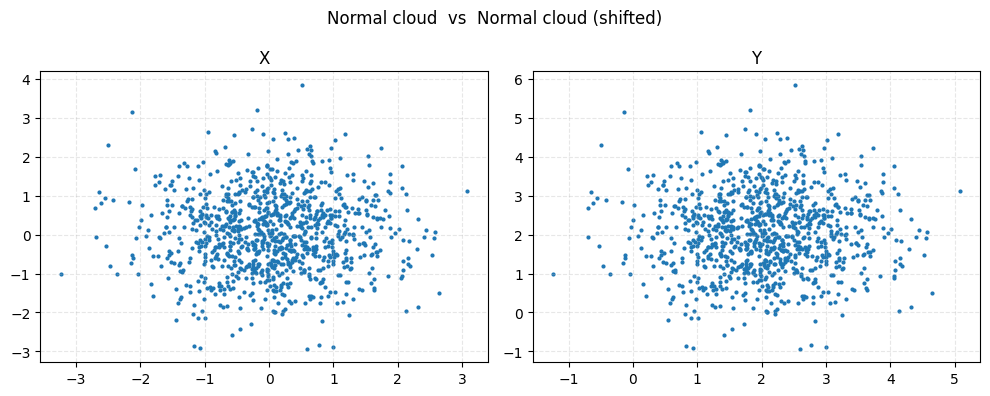


TOY PAIR: Normal cloud  vs  Normal cloud (shifted)
Shapes: X=(1000, 2), Y=(1000, 2)
=== Метод k-NN (k=10) [linear] ===
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== Метод эпсилон-окрестности [linear] ===
Выбранный адаптивный эпсилон: 0.6501
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===
Локальная метрика: 1.9968
Глобальная метрика: 1.9928 ± 0.0050


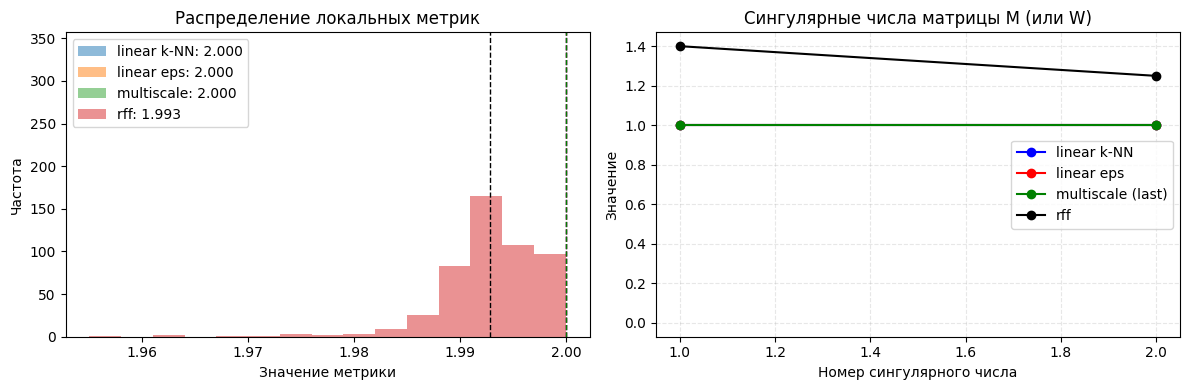


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 2
k-NN: 2.00 (100.0%)
Эпсилон: 2.00 (100.0%)
Multiscale: 2.00 (100.0%)
RFF: 1.99 (99.6%)


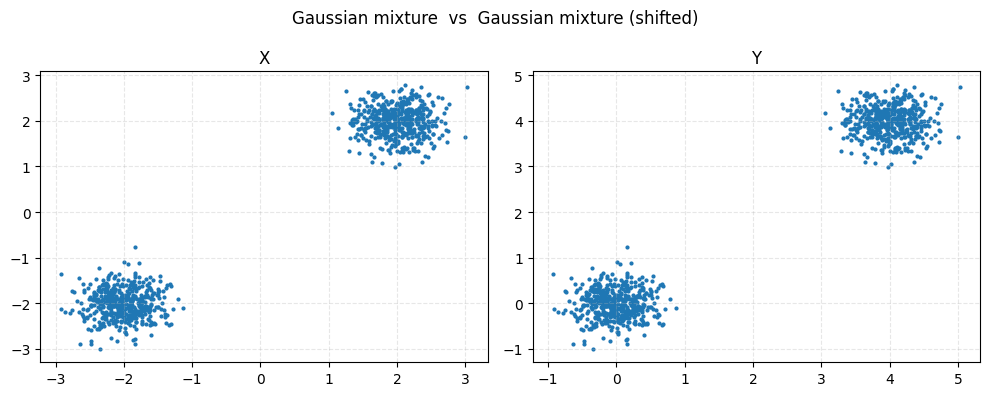


TOY PAIR: Gaussian mixture  vs  Gaussian mixture (shifted)
Shapes: X=(1000, 2), Y=(1000, 2)
=== Метод k-NN (k=10) [linear] ===
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== Метод эпсилон-окрестности [linear] ===
Выбранный адаптивный эпсилон: 0.1517
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===
Локальная метрика: 2.0000
Глобальная метрика: 2.0000 ± 0.0000

=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===
Локальная метрика: 1.9898
Глобальная метрика: 1.9935 ± 0.0036


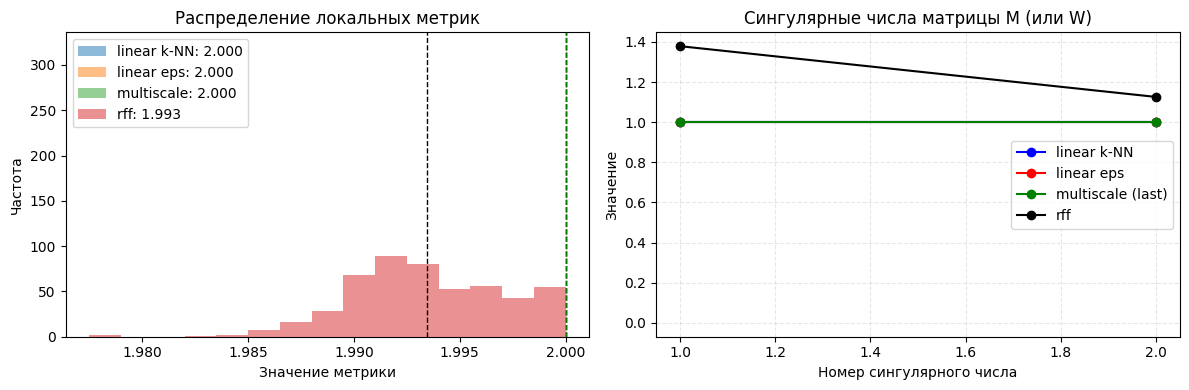


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 2
k-NN: 2.00 (100.0%)
Эпсилон: 2.00 (100.0%)
Multiscale: 2.00 (100.0%)
RFF: 1.99 (99.7%)


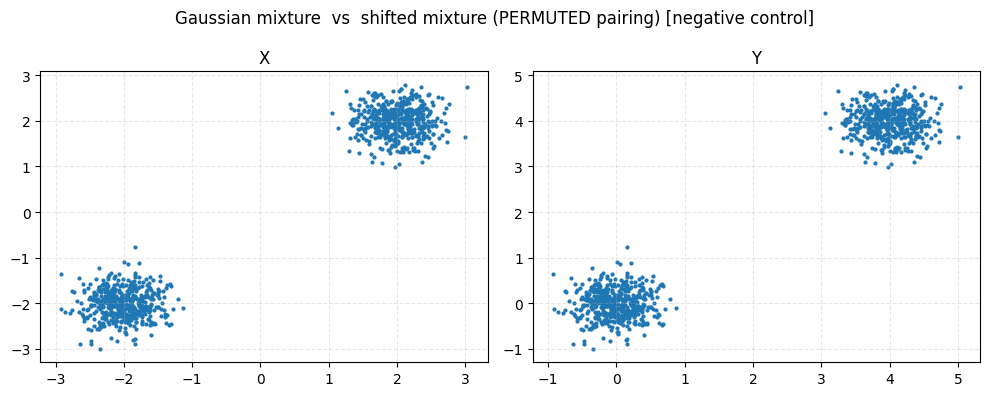


TOY PAIR: Gaussian mixture  vs  shifted mixture (PERMUTED pairing) [negative control]
Shapes: X=(1000, 2), Y=(1000, 2)
=== Метод k-NN (k=10) [linear] ===
Локальная метрика: 1.1601
Глобальная метрика: 1.2552 ± 0.2001

=== Метод эпсилон-окрестности [linear] ===
Выбранный адаптивный эпсилон: 0.1517
Локальная метрика: 1.2854
Глобальная метрика: 1.1500 ± 0.1240

=== Мульти-масштаб (k=[5,10,20,40], mean) [multiscale] ===
Локальная метрика: 1.2967
Глобальная метрика: 1.2360 ± 0.1037

=== RFF (k=10, n_features=256, gamma=1.0) [rff] ===
Локальная метрика: 1.4206
Глобальная метрика: 1.2190 ± 0.2414


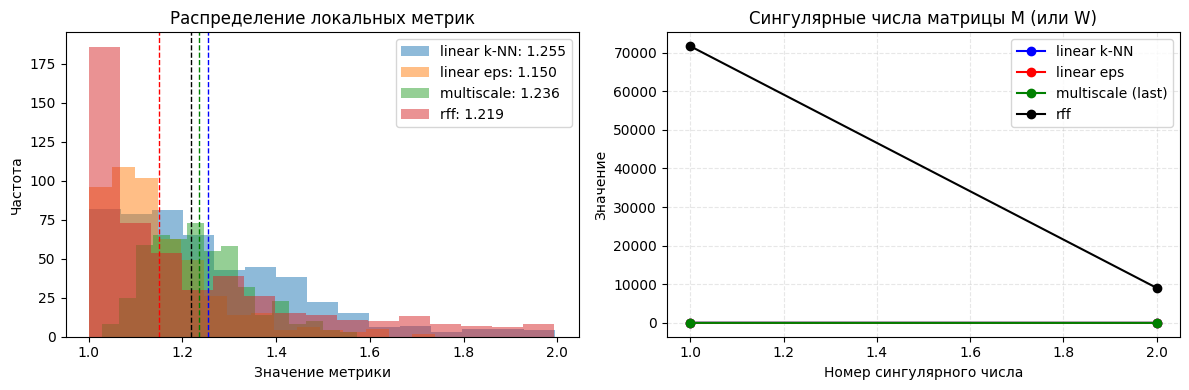


АНАЛИЗ РЕЗУЛЬТАТОВ:
Максимально возможный softrank: 2
k-NN: 1.26 (62.8%)
Эпсилон: 1.15 (57.5%)
Multiscale: 1.24 (61.8%)
RFF: 1.22 (61.0%)


In [ ]:
from scipy.stats import rv_discrete, multivariate_normal

# 1) Генератор смеси гауссиан (point_clouds.ipynb)


def sample_gaussian_mixture(K, pis, mus, sigmas, N):
    """
    K - число компонент (кластеров) [0, 1, 2, ..., K-1]
    pis - список/массив длины K - вероятности для каждого K
    mus - список из K векторов средних, каждый размера d, например [-2,-2] и [2,2]
    sigmas - список из K матриц ковариаций размера (d, d)
    N - число точек
    """
    cluster = rv_discrete(values=(np.arange(K), pis)).rvs(
        size=N
    )  # Массив длины N, каждый элемент - это номер кластера
    normal_gen = [
        multivariate_normal(mus[i], sigmas[i]) for i in range(K)
    ]  # K гауссовских генераторов
    x_result = [
        normal_gen[cluster[i]].rvs() for i in range(N)
    ]  # список длины N, каждый элемент - вектор размерности d
    return np.hstack([np.array(x_result), np.array(cluster)[:, None]])


# 2) Подготовка 3 облаков (point_clouds.ipynb)


def make_point_clouds(N=1000, d=2, seed=42):
    np.random.seed(seed)

    # Равномерное облако
    emb_normal = np.random.normal(size=(N, d))

    # Кластеры (смесь гауссиан)
    K = 2
    mus = [np.array([-2, -2]), np.array([2, 2])]
    sigmas = [np.array([[0.1, 0], [0, 0.1]]), np.array([[0.1, 0], [0, 0.1]])]
    pis = [0.5, 0.5]
    emb_clusters = sample_gaussian_mixture(
        K, pis, mus, sigmas, N
    )  # (N, 3): x,y,cluster_id

    # Кластеры 2 (смесь гауссиан) — просто сдвиг
    emb_clusters_2 = emb_clusters + 2

    return emb_normal, emb_clusters, emb_clusters_2


# 3) Привести облака к формату метрики (только координаты, без cluster_id)


def as_embeddings_2d(emb):
    """
    Отброс cluster_id.
    """
    return emb[:, :2].astype(float)


# 4) Визуализация X vs Y как в (point_clouds.ipynb)


def plot_pair_2d(X, Y, title=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], s=4)
    plt.title("X")
    plt.grid(True, alpha=0.3, linestyle="--")

    plt.subplot(1, 2, 2)
    plt.scatter(Y[:, 0], Y[:, 1], s=4)
    plt.title("Y")
    plt.grid(True, alpha=0.3, linestyle="--")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# 5)
def run_metric_on_pair(X, Y, title="", show_scatter=True):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    dim_a = X.shape[1]
    dim_b = Y.shape[1]

    if show_scatter and dim_a == 2 and dim_b == 2:
        plot_pair_2d(X, Y, title=title)

    print(f"\n{'='*80}")
    print(f"TOY PAIR: {title}")
    print(f"Shapes: X={X.shape}, Y={Y.shape}")
    print(f"{'='*80}")

    return test_comparison(X, Y)


# 6) Игрушечные пары, что подразумевает point_clouds.ipynb:
# - Normal cloud vs shifted normal cloud
# - Gaussian mixture vs shifted mixture (их emb_clusters_2)
# Плюс: “разрушающий” тест — перемешаем соответствие (контрольный негатив) ===


def run_all_repo_toys_with_your_metric(N=1000, seed=42, show_scatter=True):
    emb_normal, emb_clusters, emb_clusters_2 = make_point_clouds(N=N, d=2, seed=seed)

    # (A) Normal cloud (X) vs Shifted normal cloud (Y)
    X1 = emb_normal
    Y1 = emb_normal + 2  # как логика "shifted" в ноутбуке
    res1 = run_metric_on_pair(
        X1,
        Y1,
        title="Normal cloud  vs  Normal cloud (shifted)",
        show_scatter=show_scatter,
    )

    # (B) Gaussian mixture (X) vs Shifted Gaussian mixture (Y) — РОВНО как у них
    X2 = as_embeddings_2d(emb_clusters)
    Y2 = as_embeddings_2d(emb_clusters_2)
    res2 = run_metric_on_pair(
        X2,
        Y2,
        title="Gaussian mixture  vs  Gaussian mixture (shifted)",
        show_scatter=show_scatter,
    )

    # (C) Негативный контроль: те же точки, но нарушено соответствие по индексам
    perm = np.random.RandomState(seed + 123).permutation(X2.shape[0])
    Y3 = Y2[perm]
    res3 = run_metric_on_pair(
        X2,
        Y3,
        title="Gaussian mixture  vs  shifted mixture (PERMUTED pairing) [negative control]",
        show_scatter=show_scatter,
    )

    return {
        "normal_vs_shifted": res1,
        "mixture_vs_shifted": res2,
        "mixture_vs_shifted_permuted": res3,
    }


# 7) Запуск
toy_results = run_all_repo_toys_with_your_metric(N=1000, seed=42, show_scatter=True)

>Пояснение:

> `Normal cloud  vs  Normal cloud (shifted)`, `Gaussian mixture  vs  Gaussian mixture`проверяют метрику на инвариантность к чистому сдвигу при сохранении соотвествий точек. И так как сдавиг не меняет размерность пространства и его заполненность, метрика должна давать максимально возможное значение, то есть 2. Так и происходит. Метрика инвариантна к афинному преобразованию и глобальному сдвигу.

> `Gaussian mixture  vs  shifted mixture (PERMUTED pairing) [negative control]` - негативный контроль. В данном тесте точки в двух пространствах перемешаны друг относительно друга - геометрия расположения сохраняется, но смысла в расположении точек нет. То есть визуальное сходство распределений сохраняется, но не связь объектов. Существенный разрыв по сравнению с полностью согласованными парами подтверждает чувствительность метрики к сохранению объектного соответствия.